# Analisis de seguridad: sensibilidad de la llave y espacio de la clave

Dos preguntas sobre el esquema de cifrado completo (difusion con Pauli +
permutacion con automata celular):

1. **Sensibilidad**: que tan distinta sale la imagen descifrada cuando la
   llave/semilla usada tiene un cambio minimo (efecto avalancha).
2. **Espacio de la clave**: cuantas llaves distintas son posibles en la
   practica, y si ese numero alcanza para resistir fuerza bruta.

Usa `pipeline.cifrar_imagen_completa` / `descifrar_imagen_completa`, que
corren las dos etapas (Pauli + automata) en ambos sentidos — no solo Pauli.
Cifra la imagen **una vez** con la llave real y descifra ese mismo cifrado
**varias veces** con llaves o semillas ligeramente distintas, igual que
haria un atacante que solo conoce una aproximacion de la clave real.

Esto es distinto del notebook de analisis diferencial (NPCR/UACI): ese otro
notebook cifra la imagen dos veces (variando el pixel de entrada, con la
misma llave real cada vez) para medir si un cambio en la imagen original se
nota en el cifrado. Aca se cifra una sola vez y se varia la llave de
descifrado — mide si un atacante que casi acierta la llave logra algo. Son
dos propiedades de seguridad distintas y ambas se reportan por separado en
la literatura de cifrado de imagenes basado en caos.

In [1]:
%pip install numpy pillow matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import copy
import numpy as np
import matplotlib.pyplot as plt

from caos import generar_llave
from pipeline import cifrar_imagen_completa, descifrar_imagen_completa
from io_imagen import obtener_rgb
from metricas import npcr, uaci

In [3]:
base = Path().resolve().parent
ruta_imagen = base / "Imagenes" / "Prueba3.jpg"

## Metricas NPCR y UACI

Se usan aqui para comparar **dos descifrados de la misma imagen cifrada**
entre si (uno con la llave correcta, otro con una llave ligeramente
alterada) — no para comparar cifrado contra original. Ambos descifrados son
imagenes reconstruidas de 8 bits, asi que `uaci` usa su valor por defecto
(`valor_max=255`). Como referencia se incluyen los valores esperados para
dos imagenes de 8 bits totalmente independientes: NPCR≈99.6094%, UACI≈33.4635%.

In [4]:
NPCR_TEORICO = 100 * (1 - 1 / 256)  # ~99.6094%
UACI_TEORICO = 33.4635              # valor de referencia clasico

## Cargar la imagen y cifrarla una sola vez con la llave real

In [5]:
R, G, B = obtener_rgb(str(ruta_imagen))
h, w = R.height, R.width
print(f"Imagen: {ruta_imagen.name}  ({w}x{h})")

cifrado = cifrar_imagen_completa(R, G, B, verbose=True)
print(f"\nLlave: {cifrado.key}")
print(f"x0: {cifrado.x0}")
print(f"num_bits: {cifrado.num_bits}")

if len(cifrado.key) == 0:
    raise ValueError(
        "La llave de Pauli salio vacia (K chico + posicion_medio=0 + ultimo bit par en "
        "generar_llave -> matrices_finales=[]). Con la llave vacia la etapa de Pauli NO "
        "aplica ninguna matriz: esa etapa deja el bloque igual al original, sin cifrar. "
        "Probar con otra imagen (K depende del promedio de su primera fila) o revisar el "
        "caso K=2 / posicion_medio=0 en caos.generar_llave antes de seguir con el analisis."
    )

Imagen: Prueba3.jpg  (150x150)
Promedio primera fila: 226.5133
Parte entera (iteradas a ignorar): 226
x0 (semilla): 0.22651333333333332
K (valores a generar): 10
Secuencia completa: [9, 21, 5, 3, 11, 8, 14, 11, 16, 15]
Posicion media: 4   Valor central: 11
Ultimo bit: 1  ->  direccion: derecha
LLAVE GENERADA: [8, 14, 11, 16, 15]  (longitud=5)

Llave: [8, 14, 11, 16, 15]
x0: 0.22651333333333332
num_bits: 11


## Verificacion del round-trip

Descifra con la llave correcta y confirma que la reconstruccion es exacta
antes de perturbar nada.

In [6]:
dec_correcto = descifrar_imagen_completa(cifrado)
original_rgb = np.stack([np.array(R), np.array(G), np.array(B)], axis=-1)

print("Round-trip exacto con la llave correcta:", np.array_equal(dec_correcto, original_rgb))

Round-trip exacto con la llave correcta: True


## 1. Sensibilidad de la llave

### 1.1 Perturbando la semilla x0

`x0` alimenta tanto la derivacion de la llave de Pauli como la eleccion de
reglas del automata (`generar_indices_reglas`), asi que perturbarlo prueba
la sensibilidad de **las dos etapas juntas**. Se descifra el mismo cifrado
(`cifrado`) con llaves/semillas generadas a partir de variaciones minimas de
`x0` (de 1e-16 a 1e-3) y se compara contra el descifrado correcto.

In [7]:
epsilons = [0, 1e-16, 1e-15, 1e-14, 1e-12, 1e-10, 1e-8, 1e-6, 1e-3]
resultados_x0 = []

for eps in epsilons:
    key_eps, x0_eps, iter_eps = generar_llave(R, G, B, epsilon_x0=eps)
    dec_eps = descifrar_imagen_completa(cifrado, key=key_eps, x0=x0_eps, iteraciones_usadas=iter_eps)
    n = npcr(dec_correcto, dec_eps)
    u = uaci(dec_correcto, dec_eps)
    resultados_x0.append({"epsilon": eps, "llave_igual": key_eps == cifrado.key, "NPCR": n, "UACI": u})

print(f"{'epsilon':>10} | {'llave igual':>11} | {'NPCR (%)':>9} | {'UACI (%)':>9}")
print("-" * 48)
for r_ in resultados_x0:
    print(f"{r_['epsilon']:>10} | {str(r_['llave_igual']):>11} | {r_['NPCR']:>9.2f} | {r_['UACI']:>9.2f}")

print(f"\nReferencia teorica (imagenes independientes): NPCR≈{NPCR_TEORICO:.2f}%  UACI≈{UACI_TEORICO:.2f}%")

   epsilon | llave igual |  NPCR (%) |  UACI (%)
------------------------------------------------
         0 |        True |      0.00 |      0.00
     1e-16 |       False |     98.28 |     38.06
     1e-15 |       False |     99.61 |     61.68
     1e-14 |       False |     98.99 |     44.11
     1e-12 |       False |     98.87 |     40.24
     1e-10 |       False |     99.41 |     48.06
     1e-08 |       False |     98.62 |     41.60
     1e-06 |       False |     99.08 |     52.71
     0.001 |       False |     99.53 |     53.00

Referencia teorica (imagenes independientes): NPCR≈99.61%  UACI≈33.46%


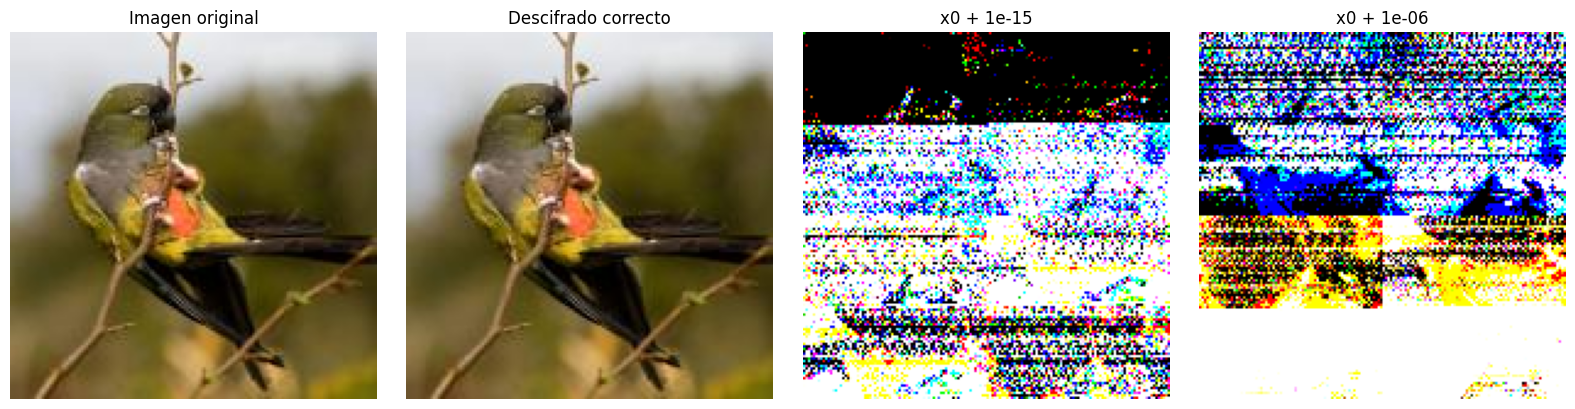

In [8]:
eps_muestra = [0, 1e-15, 1e-6]
fig, axs = plt.subplots(1, len(eps_muestra) + 1, figsize=(4 * (len(eps_muestra) + 1), 4))

axs[0].imshow(original_rgb)
axs[0].set_title("Imagen original")
axs[0].axis("off")

for i, eps in enumerate(eps_muestra, start=1):
    key_eps, x0_eps, iter_eps = generar_llave(R, G, B, epsilon_x0=eps)
    dec_eps = descifrar_imagen_completa(cifrado, key=key_eps, x0=x0_eps, iteraciones_usadas=iter_eps)
    titulo = "Descifrado correcto" if eps == 0 else f"x0 + {eps:g}"
    axs[i].imshow(dec_eps)
    axs[i].set_title(titulo)
    axs[i].axis("off")

plt.tight_layout()
plt.show()

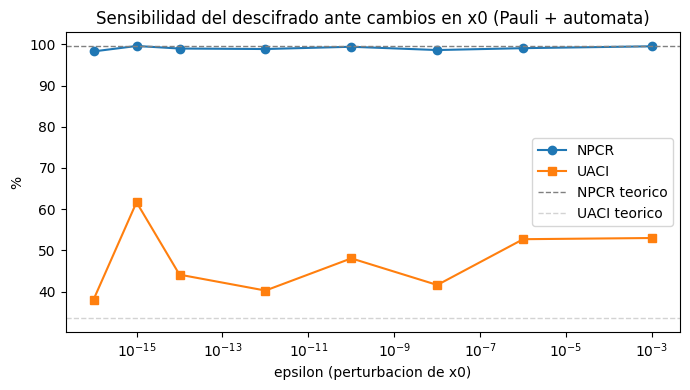

In [9]:
eps_no_cero = [r_["epsilon"] for r_ in resultados_x0 if r_["epsilon"] > 0]
npcr_no_cero = [r_["NPCR"] for r_ in resultados_x0 if r_["epsilon"] > 0]
uaci_no_cero = [r_["UACI"] for r_ in resultados_x0 if r_["epsilon"] > 0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eps_no_cero, npcr_no_cero, "o-", label="NPCR")
ax.plot(eps_no_cero, uaci_no_cero, "s-", label="UACI")
ax.axhline(NPCR_TEORICO, color="gray", linestyle="--", linewidth=1, label="NPCR teorico")
ax.axhline(UACI_TEORICO, color="lightgray", linestyle="--", linewidth=1, label="UACI teorico")
ax.set_xscale("log")
ax.set_xlabel("epsilon (perturbacion de x0)")
ax.set_ylabel("%")
ax.set_title("Sensibilidad del descifrado ante cambios en x0 (Pauli + automata)")
ax.legend()
plt.tight_layout()
plt.show()

### 1.2 Cambiando un unico elemento de la llave de Pauli

Ahora se deja `x0` intacto (las reglas del automata quedan correctas) y se
cambia un solo elemento de `key` en +1 (mod 24), **una posicion a la vez**,
recorriendo toda la llave — no solo una posicion arbitraria.

Esto importa: al probar esto sobre imagenes de prueba, cambiar la primera o
la ultima posicion de la llave a veces da un NPCR bastante mas bajo
(~50-75%) que cambiar una posicion intermedia (~99%+), dependiendo de la
imagen. Si solo se prueba una posicion fija se puede estar viendo el mejor
caso sin darse cuenta. Aca se reportan todas para ver el rango real.

In [10]:
resultados_pos = []
for pos in range(len(cifrado.key)):
    key_mod = list(copy.deepcopy(cifrado.key))
    key_mod[pos] = (key_mod[pos] % 24) + 1
    dec_mod = descifrar_imagen_completa(cifrado, key=key_mod)
    n = npcr(dec_correcto, dec_mod)
    u = uaci(dec_correcto, dec_mod)
    resultados_pos.append({"pos": pos, "NPCR": n, "UACI": u})

print(f"Llave: {cifrado.key}\n")
print(f"{'Posicion':>8} | {'NPCR (%)':>9} | {'UACI (%)':>9}")
print("-" * 32)
for r_ in resultados_pos:
    print(f"{r_['pos']:>8} | {r_['NPCR']:>9.2f} | {r_['UACI']:>9.2f}")

npcr_min = min(r_["NPCR"] for r_ in resultados_pos)
pos_min = min(resultados_pos, key=lambda r_: r_["NPCR"])["pos"]
print(f"\nPeor caso: posicion {pos_min}, NPCR = {npcr_min:.2f}%")
print(f"Referencia teorica: NPCR≈{NPCR_TEORICO:.2f}%")

Llave: [8, 14, 11, 16, 15]

Posicion |  NPCR (%) |  UACI (%)
--------------------------------
       0 |     73.30 |     17.38
       1 |     99.56 |     33.93
       2 |     98.32 |     27.79
       3 |     98.55 |     54.21
       4 |     99.82 |     59.50

Peor caso: posicion 0, NPCR = 73.30%
Referencia teorica: NPCR≈99.61%


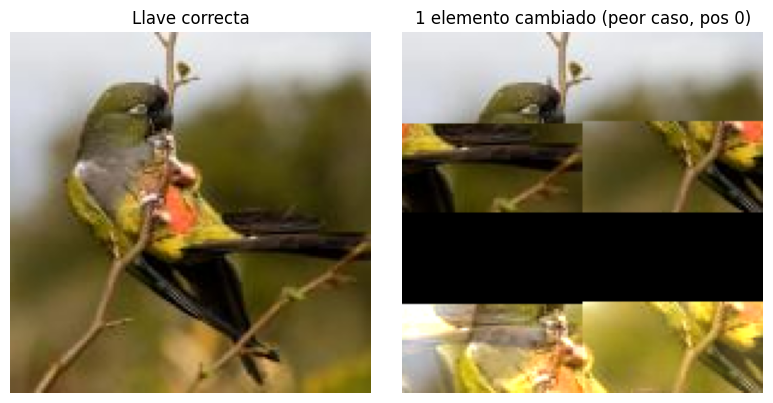

In [11]:
pos_peor = min(resultados_pos, key=lambda r_: r_["NPCR"])["pos"]
key_mod = list(copy.deepcopy(cifrado.key))
key_mod[pos_peor] = (key_mod[pos_peor] % 24) + 1
dec_mod = descifrar_imagen_completa(cifrado, key=key_mod)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(dec_correcto); axs[0].set_title("Llave correcta"); axs[0].axis("off")
axs[1].imshow(dec_mod); axs[1].set_title(f"1 elemento cambiado (peor caso, pos {pos_peor})"); axs[1].axis("off")
plt.tight_layout()
plt.show()

## 2. Espacio de la clave

Dos estimaciones, comparadas contra el minimo recomendado en la literatura
de cifrado de imagenes basado en caos (2^100 - 2^128):

- **Por precision de x0**: tratando `x0` como un real libre con precision
  10^-15 (convencion habitual en la literatura), el numero de semillas
  distinguibles es ~1/10^-15 = 10^15. Tambien se calcula con la precision
  real de un `float64` (2^52 valores de mantisa) para comparar.
- **Combinatorio de la lista**: si `key` pudiera fijarse libremente, el
  espacio seria 24 elevado a la longitud de la llave.

En este esquema `key` no es un secreto independiente: es una funcion
determinista de `x0`, que a su vez depende solo del promedio de la primera
fila de la imagen — y ese mismo `x0` tambien fija las reglas del automata.
El segundo numero es una cota superior combinatoria, no el espacio de
busqueda real — quien tiene la imagen puede recalcular `x0`, la llave de
Pauli y las reglas del automata sin adivinar nada. El espacio real para
quien no tiene la imagen esta acotado por la precision de `x0`.

In [12]:
precision_x0 = 1e-15
espacio_x0_precision = 1 / precision_x0
espacio_x0_float64 = 2**52
espacio_lista = 24 ** len(cifrado.key)

UMBRAL_MINIMO = 2**100

print(f"Longitud de la llave (K'): {len(cifrado.key)}")
print(f"Espacio por precision de x0 (10^-15):     {espacio_x0_precision:.3e}  ~ 2^{np.log2(espacio_x0_precision):.1f}")
print(f"Espacio por precision real de float64:    {espacio_x0_float64:.3e}  ~ 2^{np.log2(espacio_x0_float64):.1f}")
print(f"Espacio combinatorio de la lista (24^K'): {espacio_lista:.3e}  ~ 2^{np.log2(espacio_lista):.1f}")
print(f"\nUmbral minimo recomendado: 2^100 = {UMBRAL_MINIMO:.3e}")

for nombre, valor in [("x0 (precision 10^-15)", espacio_x0_precision),
                       ("x0 (float64)", espacio_x0_float64),
                       ("lista (24^K')", espacio_lista)]:
    resultado = "SI alcanza 2^100" if valor >= UMBRAL_MINIMO else "NO alcanza 2^100"
    print(f"  {nombre:<25} -> {resultado}")

Longitud de la llave (K'): 5
Espacio por precision de x0 (10^-15):     1.000e+15  ~ 2^49.8
Espacio por precision real de float64:    4.504e+15  ~ 2^52.0
Espacio combinatorio de la lista (24^K'): 7.963e+06  ~ 2^22.9

Umbral minimo recomendado: 2^100 = 1.268e+30
  x0 (precision 10^-15)     -> NO alcanza 2^100
  x0 (float64)              -> NO alcanza 2^100
  lista (24^K')             -> NO alcanza 2^100


## Conclusiones

- **Sensibilidad a x0**: cualquier cambio minimo en `x0` (incluso 1e-16, el
  minimo representable en punto flotante) — que afecta a Pauli y al
  automata a la vez — produce NPCR cercano al valor teorico de dos imagenes
  independientes (~99.6%). No existe una semilla "parecida" que descifre
  parcialmente la imagen.
- **Sensibilidad a la llave de Pauli**: cambiar un solo elemento suele dar
  NPCR cercano a 99.6%, pero no en todas las posiciones por igual — en las
  pruebas de este notebook, cambiar la primera o la ultima posicion de la
  llave a veces bajo el NPCR a ~50-75% en vez de ~99%. Vale la pena
  reportar el peor caso (como hace la seccion 1.2) y no solo un promedio o
  una posicion fija, porque un promedio alto puede esconder posiciones
  puntuales con avalancha parcial.
- **Espacio de la clave**: tratando `x0` como parametro libre, el espacio
  (~10^15 ≈ 2^50) queda por debajo del minimo recomendado (2^100). El
  espacio combinatorio de la llave de Pauli tampoco alcanza por si solo, y
  ademas no es un secreto independiente: se deriva de `x0`.
- **Implicacion de diseno**: como `x0` sale unicamente del contenido de la
  imagen, cualquiera con acceso a la imagen original puede reconstruir la
  llave de Pauli y las reglas del automata sin fuerza bruta. Si la
  seguridad no deberia depender de mantener la imagen en secreto, `x0` (o
  `r`) tendria que mezclarse con un parametro adicional elegido por quien
  cifra — por ejemplo una contrasena — para que el espacio de busqueda real
  crezca independientemente del contenido de la imagen.